# OASIS pilot → AnnData

OASIS pilot plates ([`cpg0033`](https://broadinstitute.github.io/cellpainting-gallery/)) spanning U2OS and HepaRG assay development batches.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0033-oasis-pilot/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0033-oasis-pilot/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

4 batches, using 2024_11_15_OASIS_HepaRG_AD


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

AnnData object with n_obs × n_vars = 2303 × 720
    obs: 'plate_map_name', 'source_plate', 'source_well_position', 'destination_plate', 'BROAD_ID', 'assay_conc_uM', 'Source', 'Vendor Catalog ID', 'Compound Name', 'Annotation', 'Smiles', 'cell_line', 'cells_per_well', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "plate_map_name", "pert_type", "control_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_10_DNA,image,granularity,dna,NaN,1
Image_Granularity_10_ER,image,granularity,er,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1
...,...,...,...,...,...
Nuclei_Texture_InfoMeas2_RNA_10_03_256,nuclei,texture,rna,NaN,1
Nuclei_Texture_InverseDifferenceMoment_AGP_10_01_256,nuclei,texture,agp,NaN,1
Nuclei_Texture_InverseDifferenceMoment_RNA_3_02_256,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate", "plate_map_name"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

2,303 wells x 718 features
non-finite: 0 | max|x|: 10833.0

Plate:
Plate
BR00145691    384
BR00145692    384
BR00145693    384
BR00145694    384
BR00145695    384
BR00145690    383

plate_map_name:
plate_map_name
BR00145691    384
BR00145692    384
BR00145693    384
BR00145694    384
BR00145695    384
BR00145690    383


In [6]:
adata.write_h5ad(PROFILES.parent / "oasis_pilot.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "plate_map_name"]))

,observed,baseline,ratio
covariate,,,
Plate,0.317,0.167,1.901
plate_map_name,0.317,0.167,1.901


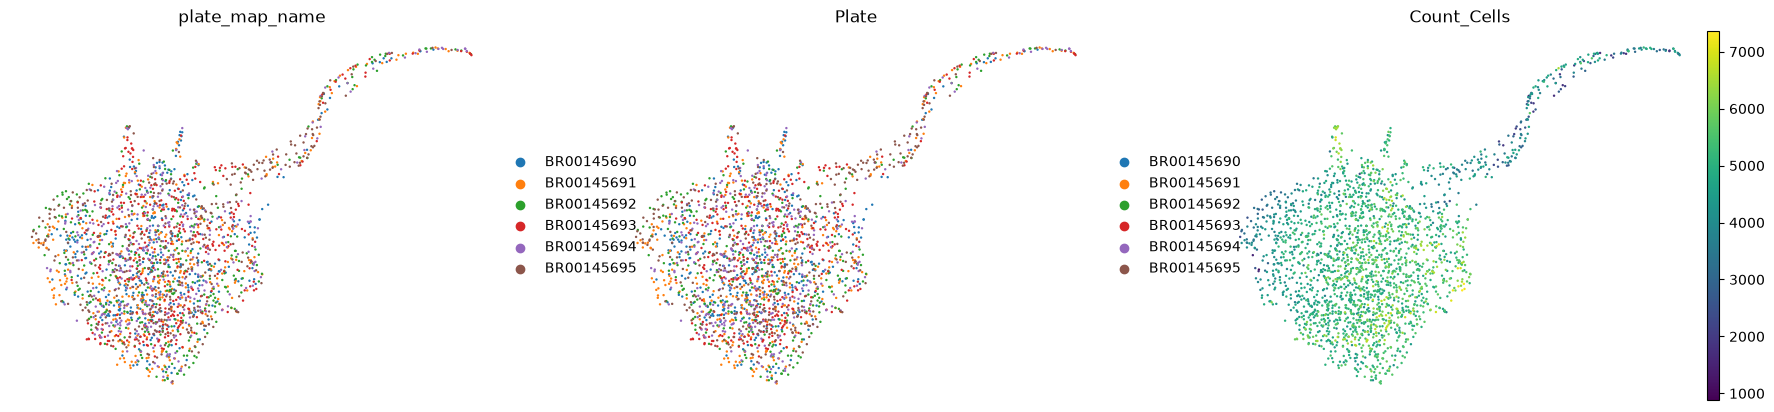

In [9]:
sc.pl.umap(adata, color=present(["plate_map_name", "Plate", "Count_Cells"])[:3], ncols=3, frameon=False, size=12)